In [6]:
import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import numpy as np
import math

%matplotlib inline

### Class Activity 1

#### 1.Why do we not get only `0` as the result?  
because the Hadamard `H` gate puts the qubit into a state of superposition,   
a qubit in superposition exists in a state where it has an equal probability of both outcomes

#### 2.Are the counts exactly equal? Why or why not?  
The counts are usually not exactly equal because quantum measurement is probabilistic so the result of n number of trials has slight variation AROUND 50%.  

#### 3.What do you think will happen if the `H` gate is removed?  
If the `H` gate is removed, the measurement result will be 100% 0.

### Try it yourself

Circuit:


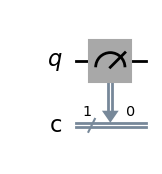

Measurement counts: {'0': 1024}


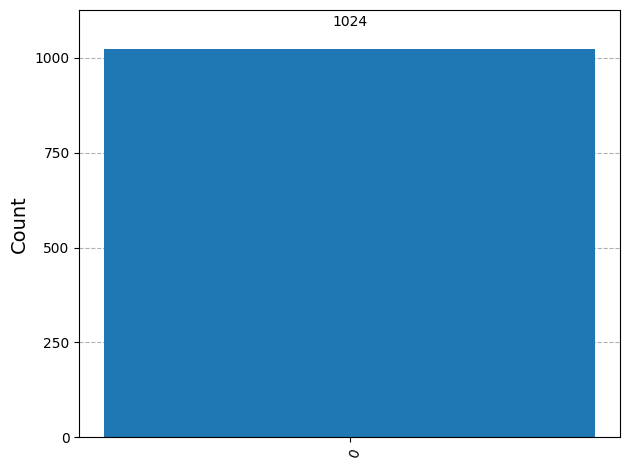

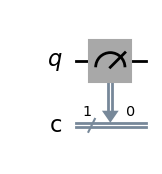

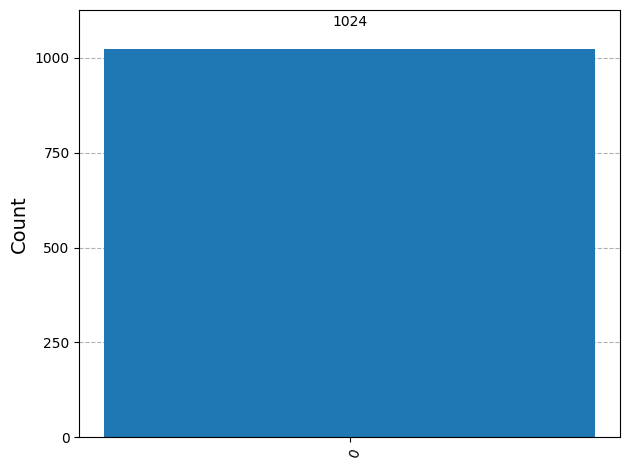

In [10]:
# - remove the `H` gate and run again


qc1 = QuantumCircuit(1, 1)
# qc1.h(0) 
qc1.measure(0, 0)

print("Circuit:")
display(qc1.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts(qc1)

print("Measurement counts:", counts)
plot_histogram(counts)

Outcome: The result is always 0 because the qubit remains in its initial state

Circuit:


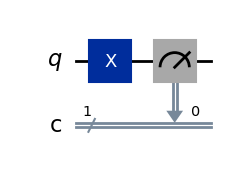

Measurement counts: {'1': 1024}


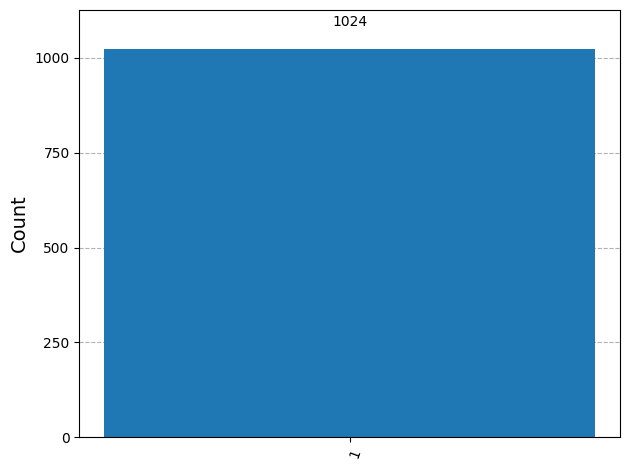

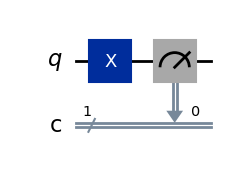

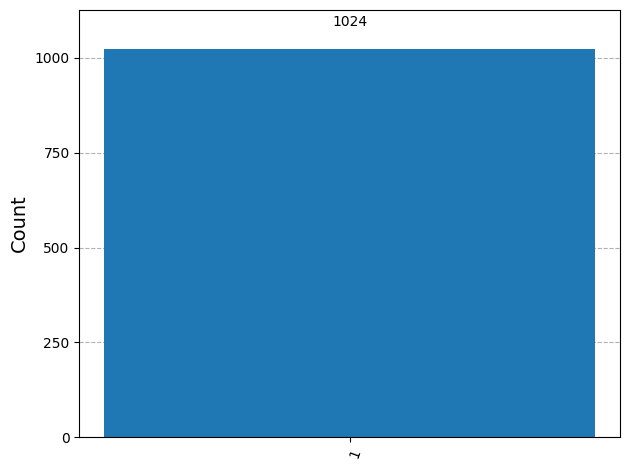

In [11]:
# replace `qc1.h(0)` with `qc1.x(0)` and run again
qc1 = QuantumCircuit(1, 1)
qc1.x(0) #X gate (NOT gate)
qc1.measure(0, 0)

print("Circuit:")
display(qc1.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts(qc1)

print("Measurement counts:", counts)
plot_histogram(counts)

Outcome: The result is always 1 because the X gate performs a bit-flip,

### Class Activity 2

#### 1.Why are there four possible outputs now?  
because each qubit is in a superposition of two states. it can exist in any of the four possible combinations: 00, 01, 10, or 11.

#### 2. Which output appears most often? Is that what you expected? 
All four outputs have an equal 25% probability 

#### 3.If you apply `X` to qubit 0 before the `H`, how does the result change?
The final result remains unchanged. The `x` gate changes 0 into 1 then apply `H` still gives it a 50/50 superposition.

### Extension

Circuit:


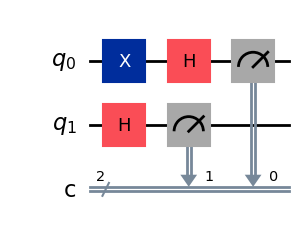

Measurement counts: {'11': 247, '10': 257, '01': 255, '00': 265}


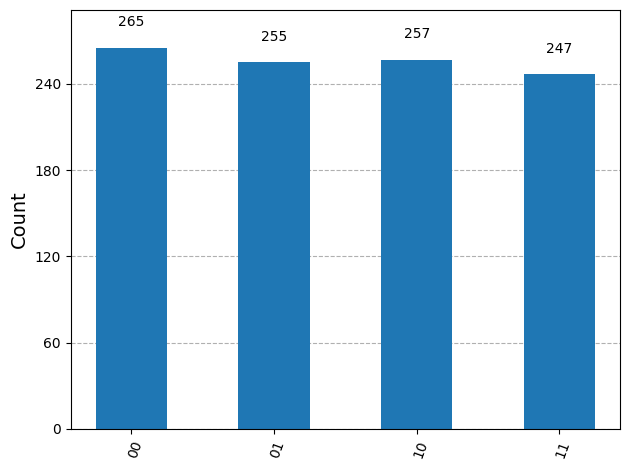

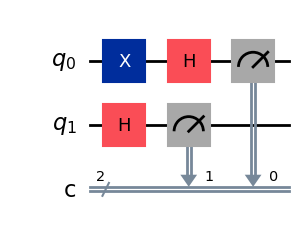

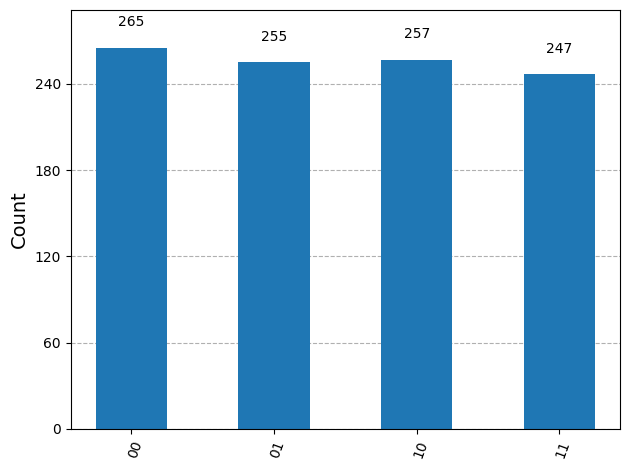

In [12]:
# apply `X` on qubit 0 before measurement

qc2 = qk.QuantumCircuit(2, 2)

qc2.x(0)
qc2.h(0)
qc2.h(1)
qc2.measure(0, 0)
qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1024)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

Outcome : The results remain roughly equal (25% each)

Circuit:


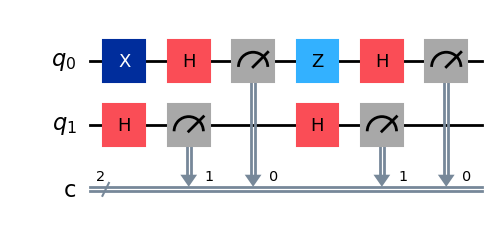

Measurement counts: {'10': 250, '01': 242, '00': 269, '11': 263}


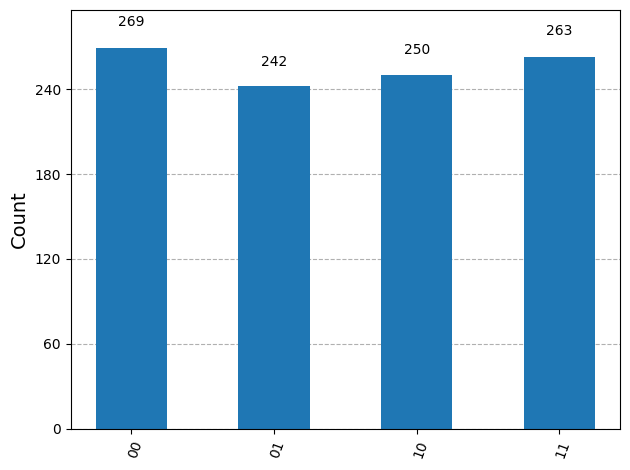

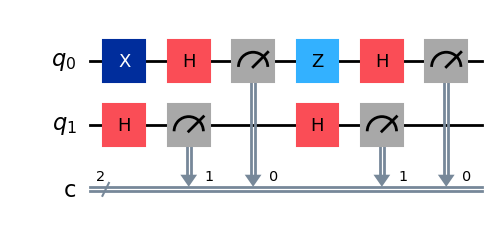

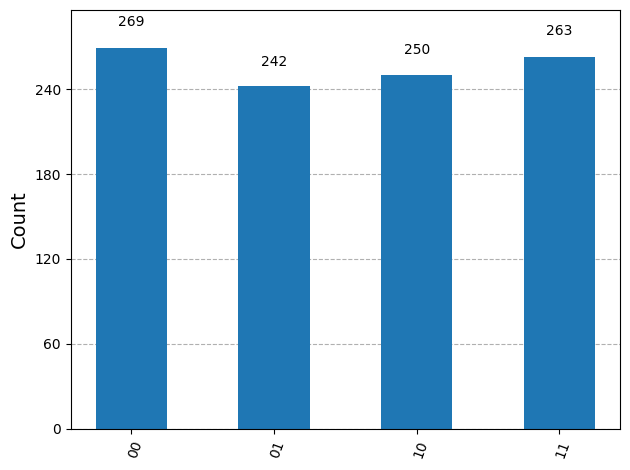

In [13]:
# apply `Z` on qubit 0 before measurement

qc2.z(0)
qc2.h(0)
qc2.h(1)
qc2.measure(0, 0)
qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1024)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

In [ ]:
Outcome : The results remain roughly equal (25% each). Z gate only performs a phase flip.

Circuit:


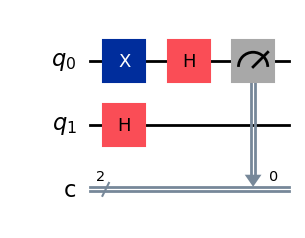

Measurement counts: {'01': 528, '00': 496}


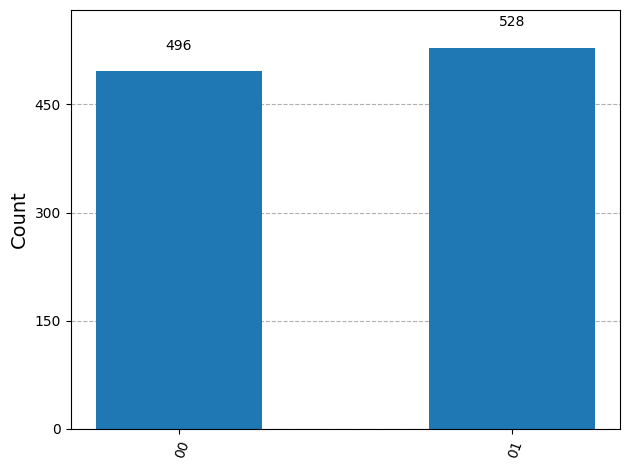

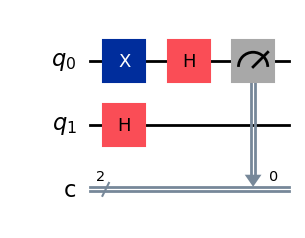

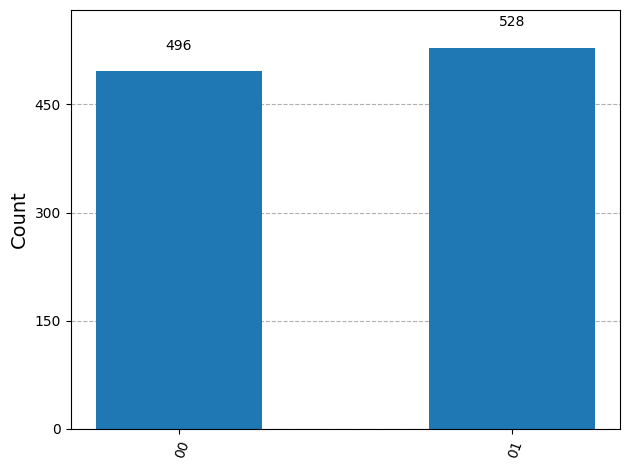

In [14]:
#  measure only one qubit and leave the other unmeasured

qc2 = qk.QuantumCircuit(2, 2)

qc2.x(0)
qc2.h(0)
qc2.h(1)
qc2.measure(0, 0)


print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1024)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

Outcome : only result for the measures qubit (0 or 1). histogram has two bars instead of four.

### Class Activity 3

#### 1. Why do we mainly see `00` and `11`, but not `01` and `10`?
because the qubits are correlated. If the first qubit is measured as 0, the second is forced to be 0, and if the first is 1, the second must be 1

#### 2. How is this different from the earlier two-qubit superposition example? 
In the previous example (qc2), the qubits were independent, four possible outcomes (00,01,10,11)

#### 3. What role does the `cx` gate play?
The cx gate is the entangler.

### Try it yourself

Circuit:


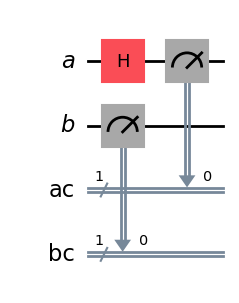

Measurement counts: {'0 1': 2018, '0 0': 2078}


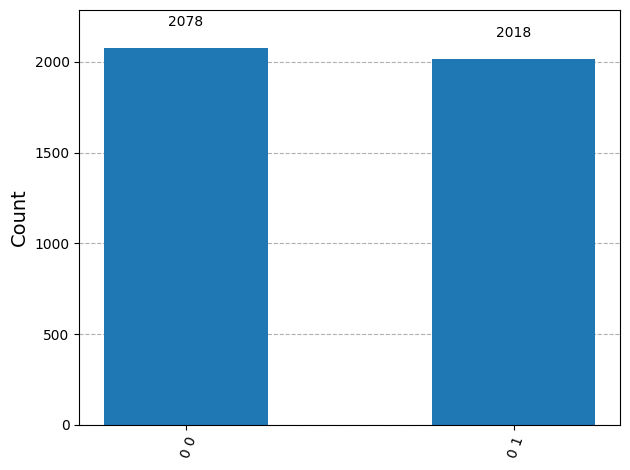

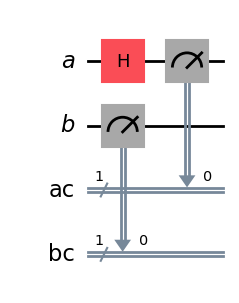

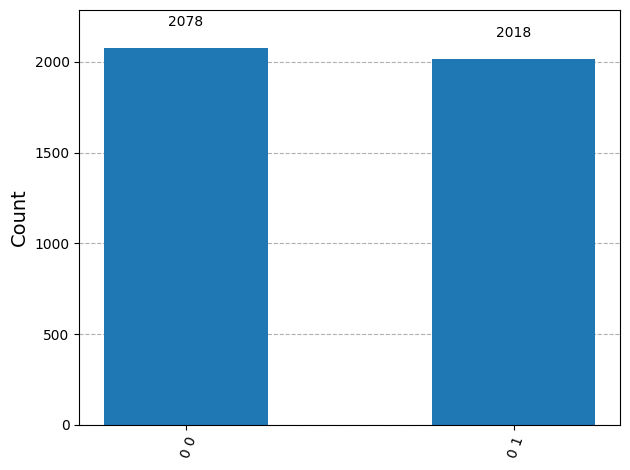

In [16]:
# remove the `cx` gate
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition
#qc3.cx(a[0], b[0])   # entangle qubit a and qubit b
qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

Outcome : the entanglement is broken. qubit 0 is in superposition and qubit 1 remains 0.

Circuit:


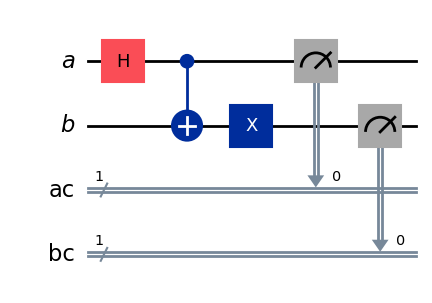

Measurement counts: {'1 0': 2072, '0 1': 2024}


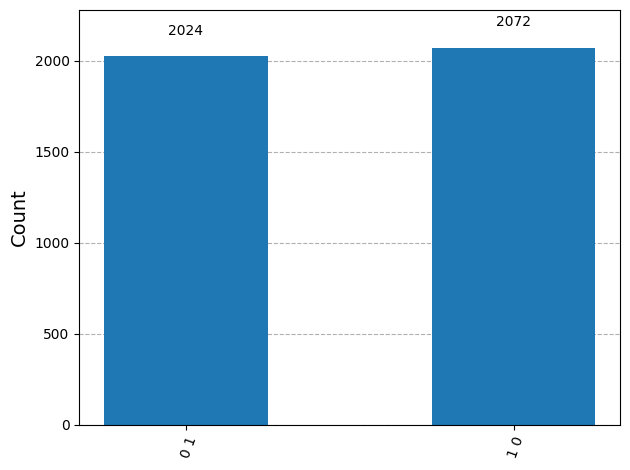

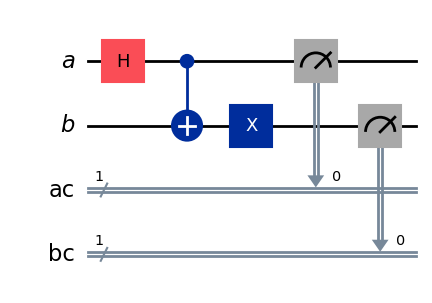

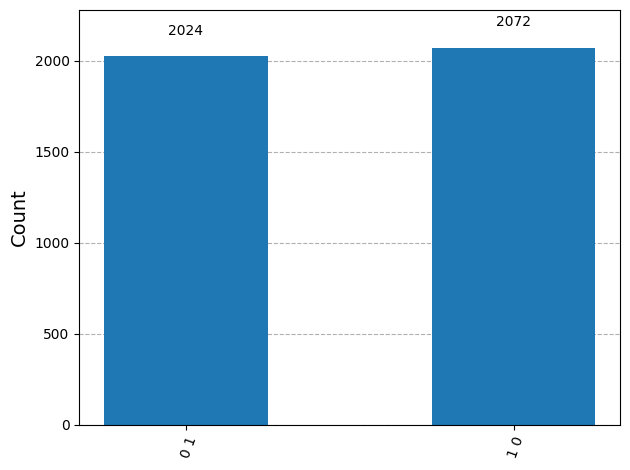

In [17]:
# apply `x` to qubit `b` before measurement
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition
qc3.cx(a[0], b[0])   # entangle qubit a and qubit b
qc3.x(b[0])
qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

Outcome : Instead of 00 and 11, now there is 01 and 10.

still entangled, but now "anti-correlated"

Circuit:


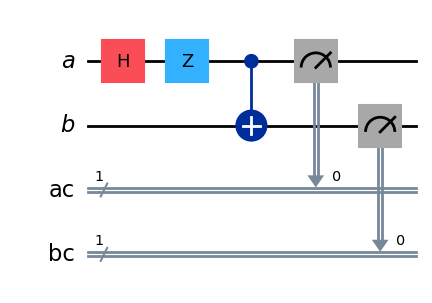

Measurement counts: {'0 0': 1986, '1 1': 2110}


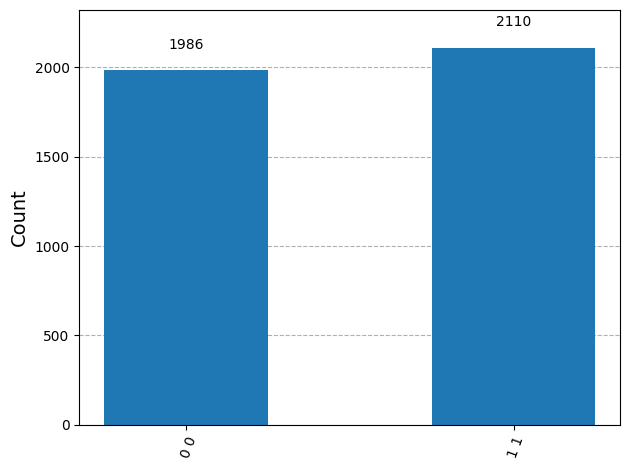

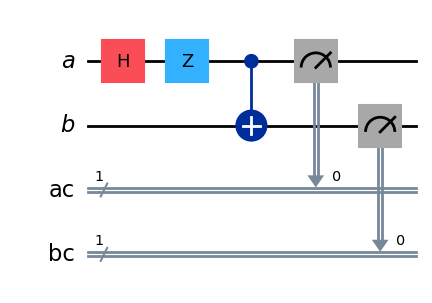

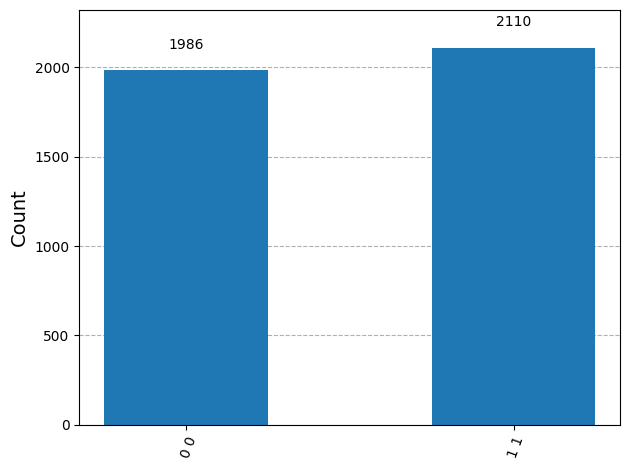

In [19]:
# apply `z` to qubit `a` before the `cx`

a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition
qc3.z(a[0])
qc3.cx(a[0], b[0])   # entangle qubit a and qubit b
qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

Outcome : The Z gate changes the phase of the superposition. Measurement is still same.

### Class Activity 4

#### 1. Where is \(|0\rangle\)?
It is located at the North Pole of the Bloch Sphere.

#### 2. Where is \(|1\rangle\)?
It is located at the South Pole of the Bloch Sphere.

#### 3. What type of state is created by `H|0>`?
It creates a superposition state.

#### 4. Why is the Bloch Sphere mainly useful for only one qubit?
because the complexity of quantum states grow exponentially as more qubits are added.

### Class activity 5

1. Which gate produced a clear flip between \(|0\rangle\) and \(|1\rangle\)?  
The X gate.  it moved the state from the North Pole ($|0\rangle$) to the South Pole ($|1\rangle$) of the Bloch sphere.

2. Which gate changed the phase of a superposition state?  
The Z gate. After H gate created superposition, $Z$ gate rotated the state $180^\circ$ around the Z-axis.

3. Why can two states give different Bloch positions even when probabilities may look similar?  
because of relative phase.


Your circuit:


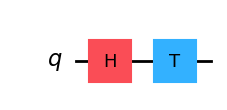

Statevector: Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


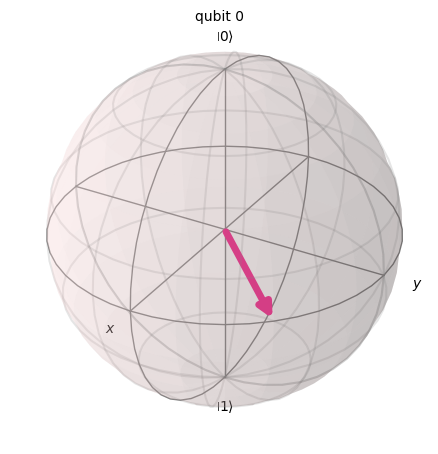

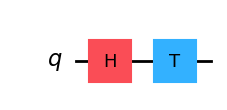

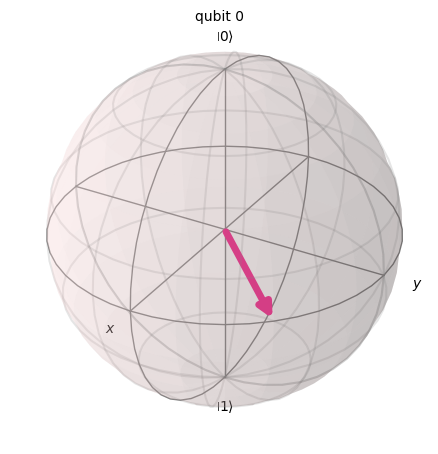

In [13]:
qc_student = QuantumCircuit(1)

# Applying a Hadamard gate to create superposition
qc_student.h(0)
# Applying a T gate for a 45-degree phase rotation
qc_student.t(0)

print("Your circuit:")
display(qc_student.draw(output='mpl'))

state_student = Statevector.from_instruction(qc_student)
print("Statevector:", state_student)
plot_bloch_multivector(state_student)

## 7. Tasks
1. Build a circuit with at least **two gates**.  above with H and T gate
2. Predict the Bloch Sphere position before running it.  The vector will lie on the equator (XY-plane), $45^\circ$
3. Plot the Bloch Sphere. above.
4. Write a 3 to 5 line explanation of what happened.  The Hadamard ($H$) gate first creates superposition. The $T$ gate then applies a $\pi/4$ phase shift, which rotates the state vector $45^\circ$ clockwise around the Z-axis. 

## 8. Reflection questions

Write short answers for the following:
  
1. What is the difference between a classical bit and a qubit?  <br> A classic bit exists as either 0 or 1. A qubit can exist in superposition of both 0 and 1 simultaneously.
2. What does the Hadamard gate do?  <br> The Hadmard gate cerates superposition. 
3. How is an entangled state different from two independent qubits in superposition?  In independent superposition, each qubit and be described individually. (qubitA is 50/50  and also qubitB is 50/50. In entangled state, quibits are linked and the state of one cannot be described  without other. 
4. What does the Bloch Sphere help us understand?  <br> It helps us to visualize probability and phase of a single qubit.
5. Which part of today's lab did you find the most interesting or confusing?


## 9. Optional assessment task

Submit the following:
- one screenshot of a circuit you created  
  uploaded as screenshot_ht_circuit
- one histogram or Bloch Sphere output  
  uploaded as screenshot_ht_blochsphere  
- a short explanation of what your circuit does  
  Hadamard (H) Gate: This gate transforms the qubit to superposition state. T Gate: Once the qubit is in superposition, the T gate applies a phase rotation of $45^\circ$ around the Z-axis.